# AICE Associate 대비 실습 과정 — 8회차 (마지막)
## 비지도학습, 모델 성능 향상시키기, 종합 모의 실습

> **과정 구성**: 총 8회 × 3시간, 실습 위주  
> **선수 학습**: 1~7회차 전체  
> **데이터**: **캘리포니아 주택** (군집·차원 축소·회귀 튜닝), **타이타닉** (군집·교차검증·분류 튜닝·모의 실습)

### 전체 커리큘럼

| 회차 | 주제 | 핵심 키워드 |
|:---:|------|------------|
| 1 | AI/ML/DL 개요, 데이터 획득하기 | AI ⊃ ML ⊃ DL, 지도/비지도, `read_csv`, `read_excel`, `to_csv` |
| 2 | 데이터 구조 확인하기, 기초 데이터 다루기 | `info`, `describe`, `loc/iloc`, 필터링, 정렬, `groupby`, `merge` |
| 3 | 데이터 이해하기 (EDA) | 분포, 상관관계, `matplotlib`, `seaborn`, 가설 검증 |
| 4 | 데이터 전처리하기 | 결측치, 이상치, 구간화, 인코딩, 스케일링, `train_test_split` |
| 5 | AI 모델링 필수 개념, 지도학습 I | 과적합, 평가지표, 선형회귀, 로지스틱 회귀 |
| 6 | 지도학습 II | 의사결정나무, 앙상블, 랜덤포레스트, 그라디언트부스팅 |
| 7 | 인공신경망, 심층신경망, 딥러닝 프레임워크 | 퍼셉트론, 활성화함수, Keras `Sequential`, `EarlyStopping` |
| **8** | **비지도학습, 모델 성능 향상시키기** | K-Means, PCA, 교차검증, 하이퍼파라미터 튜닝, 모의고사 |

### 오늘의 학습 목표

1. 지도학습과 비지도학습의 차이를 설명하고, 군집·차원 축소가 언제 쓰이는지 안다.
2. K-Means 로 군집을 만들고 엘보우·실루엣으로 군집 수를 고르며, 군집을 해석할 수 있다.
3. PCA 로 차원을 줄이고 설명된 분산 비율을 해석할 수 있다.
4. 교차검증으로 성능을 안정적으로 평가하고, Pipeline 으로 정보 누출 없이 전처리를 묶을 수 있다.
5. GridSearchCV / RandomizedSearchCV 로 하이퍼파라미터를 튜닝할 수 있다.
6. 불균형 데이터 대응과 변수 선택으로 성능을 개선할 수 있다.
7. AICE 형식 문제를 처음부터 끝까지 시간 안에 풀 수 있다.

### 시간 계획 (180분)

| 시간 | 내용 |
|------|------|
| 00:00 ~ 00:05 | 0. 환경 준비 |
| 00:05 ~ 01:00 | 1. 비지도학습 (K-Means, 계층적 군집, PCA) |
| 01:00 ~ 01:10 | 휴식 |
| 01:10 ~ 02:05 | 2. 모델 성능 향상 (교차검증, Pipeline, 튜닝, 불균형, 변수 선택) |
| 02:05 ~ 02:10 | 휴식 |
| 02:10 ~ 03:00 | 3. 종합 모의 실습 (AICE 형식), 과정 정리 |

---
## 0. 환경 준비

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

DATA_DIR = "data"
RANDOM_STATE = 42

In [2]:
# 한글 폰트 설정 (1회차와 동일). Colab 은 나눔폰트 설치 후 런타임 재시작 필요.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0], rc={"axes.unicode_minus": False})

적용된 폰트: AppleGothic


In [3]:
# ===== 실습 데이터: 캘리포니아 주택 가격(회귀), 타이타닉 생존(분류) =====
# data/ 폴더에 아래 파일이 있어야 합니다. (Colab 이면 왼쪽 파일 탭에서 data/ 폴더를 만들고 업로드)
#   california_housing_train.csv, california_housing_test.csv, titanic_train.csv, titanic_test.csv
# 원본 컬럼명은 영어라서 읽은 뒤 한글로 바꿉니다. (영어 = 한글 대응표는 아래 사전 참고)

HOUSING_COLS = {
  "longitude": "경도",                 # 서쪽일수록 작은 값 (-124 ~ -114)
  "latitude": "위도",                  # 북쪽일수록 큰 값 (32 ~ 42)
  "housing_median_age": "주택연식",    # 그 구역 주택 나이의 중앙값 (년)
  "total_rooms": "총방수",             # 구역 내 전체 방 수
  "total_bedrooms": "총침실수",        # 구역 내 전체 침실 수
  "population": "인구",                # 구역 인구
  "households": "가구수",              # 구역 가구 수
  "median_income": "소득중앙값",       # 가구 소득 중앙값 (단위: 만 달러)
  "median_house_value": "주택가격",    # 구역 주택 가격의 중앙값 (달러) <- 회귀 타깃
}
TITANIC_COLS = {
  "PassengerId": "승객ID",
  "Survived": "생존",                  # 1 = 생존, 0 = 사망 <- 분류 타깃
  "Pclass": "객실등급",                # 1등석 / 2등석 / 3등석
  "Name": "이름",
  "Sex": "성별",                       # male / female
  "Age": "나이",
  "SibSp": "동반형제배우자",           # 함께 탄 형제·배우자 수
  "Parch": "동반부모자녀",             # 함께 탄 부모·자녀 수
  "Ticket": "티켓번호",
  "Fare": "운임",                      # 지불한 요금 (파운드)
  "Cabin": "객실번호",
  "Embarked": "탑승항구",              # C = Cherbourg, Q = Queenstown, S = Southampton
}

for name in ["california_housing_train.csv", "california_housing_test.csv", "titanic_train.csv", "titanic_test.csv"]:
  if not os.path.exists(f"{DATA_DIR}/{name}"):
    raise FileNotFoundError(f"{DATA_DIR}/{name} 가 없습니다. data 폴더에 실습 파일을 넣어 주세요.")

housing = pd.read_csv(f"{DATA_DIR}/california_housing_train.csv").rename(columns=HOUSING_COLS)
housing_test = pd.read_csv(f"{DATA_DIR}/california_housing_test.csv").rename(columns=HOUSING_COLS)
titanic = pd.read_csv(f"{DATA_DIR}/titanic_train.csv").rename(columns=TITANIC_COLS)
titanic_test = pd.read_csv(f"{DATA_DIR}/titanic_test.csv").rename(columns=TITANIC_COLS)

print("housing:", housing.shape, "| housing_test:", housing_test.shape)
print("titanic:", titanic.shape, "| titanic_test:", titanic_test.shape)

housing: (17000, 9) | housing_test: (3000, 9)
titanic: (891, 12) | titanic_test: (418, 11)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def preprocess_titanic(df: pd.DataFrame) -> pd.DataFrame:
  '''타이타닉 전처리 (5~7회차와 동일한 규칙)'''
  out = df.drop(columns=["승객ID", "이름", "티켓번호", "객실번호"])
  out["나이"] = out["나이"].fillna(out["나이"].median())
  out["탑승항구"] = out["탑승항구"].fillna(out["탑승항구"].mode()[0])
  out["가족수"] = out["동반형제배우자"] + out["동반부모자녀"] + 1
  out["혼자탑승"] = (out["가족수"] == 1).astype(int)
  out["성별"] = out["성별"].map({"male": 0, "female": 1})
  return pd.get_dummies(out, columns=["탑승항구"], drop_first=True, dtype=int)


def add_features(df: pd.DataFrame) -> pd.DataFrame:
  '''주택 파생 변수 (5~7회차와 동일)'''
  out = df.copy()
  out["가구당방수"] = out["총방수"] / out["가구수"]
  out["침실비율"] = out["총침실수"] / out["총방수"]
  out["가구당인구"] = out["인구"] / out["가구수"]
  return out


titanic_clean = preprocess_titanic(titanic)
Xc = titanic_clean.drop(columns=["생존"])
yc = titanic_clean["생존"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

housing_fe = add_features(housing)
Xr = housing_fe.drop(columns=["주택가격"])
yr = housing_fe["주택가격"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)
print("타이타닉:", Xc_train.shape, Xc_test.shape, "| 주택:", Xr_train.shape, Xr_test.shape)

타이타닉: (712, 10) (179, 10) | 주택: (13600, 11) (3400, 11)


---
# Part 1. 비지도학습

## 1.1 비지도학습이란

### 한 줄 정의
**정답(y) 없이** 데이터 자체의 구조(비슷한 것끼리의 묶음, 정보가 몰린 방향)를 찾는 학습.

| 구분 | 지도학습 (5~7회차) | 비지도학습 (오늘) |
|------|------|------|
| 정답 y | **있음** (생존, 가격) | **없음** |
| 질문 | "이 승객은 살았을까?" | "승객들은 어떤 무리로 나뉘나?" |
| 대표 작업 | 분류, 회귀 | **군집 (clustering)**, **차원 축소 (dimensionality reduction)**, 이상 탐지 |
| 대표 알고리즘 | 로지스틱 회귀, 랜덤포레스트, DNN | **K-Means**, 계층적 군집, DBSCAN, **PCA** |
| 평가 | 정답과 비교 (정확도, RMSE) | 정답이 없어 **간접 지표** (실루엣, 설명된 분산) + **사람의 해석** |
| 실무 예 | 이탈 예측, 가격 예측 | **고객 세분화**, 상권 묶기, 변수 압축, 시각화 |

> 비지도학습은 그 자체로 끝나기보다 **지도학습의 재료** 가 되는 경우가 많습니다. 1.4 에서 군집 결과를 회귀 모델의 새 변수로 써서 성능을 올려 봅니다.

## 1.2 K-Means 군집

### 한 줄 정의
데이터를 **K 개의 무리** 로 나누되, 각 점이 **가장 가까운 중심점(centroid)** 의 무리에 속하도록 하는 알고리즘.

### 직관적 설명
운동장에 흩어진 학생들을 K 개 반으로 나누는 상황입니다.

```
① 반장 K 명을 아무렇게나 뽑는다 (초기 중심)
② 모든 학생이 가장 가까운 반장에게 간다 (배정)
③ 각 반의 한가운데로 반장이 자리를 옮긴다 (중심 갱신)
④ ②~③ 을 반복하다가 반장이 더 이상 움직이지 않으면 끝
```

| 파라미터 | 의미 |
|------|------|
| `n_clusters` | K, 군집 수. **사람이 정해야 함** (1.2.2 에서 고르는 법) |
| `n_init` | 초기 중심을 몇 번 다르게 뽑아 가장 좋은 결과를 쓸지 (기본 버전마다 다름, **10 명시 권장**) |
| `random_state` | 재현성 |

### 1.2.1 위치로 구역 묶기 (캘리포니아 주택)

군집별 구역 수: [5899, 3184, 1127, 440, 1441, 1509]


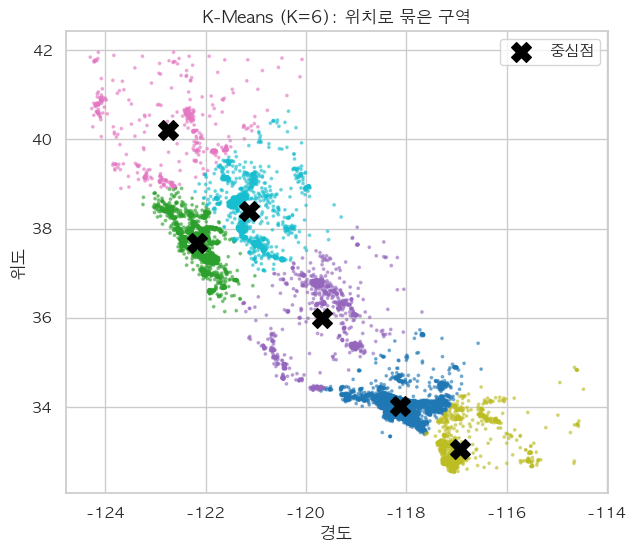

In [5]:
from sklearn.cluster import KMeans

loc_train = Xr_train[["위도", "경도"]]        # 위도·경도는 같은 단위(도)라 스케일링 없이도 거리 의미가 맞다
kmeans = KMeans(n_clusters=6, n_init=10, random_state=RANDOM_STATE)
kmeans.fit(loc_train)                          # y 가 없다! 입력만 준다

labels = kmeans.labels_                        # 각 구역의 군집 번호 (0~5)
centers = kmeans.cluster_centers_              # 중심점 6개의 (위도, 경도)
print("군집별 구역 수:", np.bincount(labels).tolist())

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(loc_train["경도"], loc_train["위도"], c=labels, cmap="tab10", s=3, alpha=0.5)
ax.scatter(centers[:, 1], centers[:, 0], c="black", marker="X", s=200, label="중심점")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_title("K-Means (K=6): 위치로 묶은 구역")
ax.legend()
plt.show()

In [6]:
# 군집 해석: 정답(가격)을 학습에 쓰지 않았지만, 묶인 결과를 가격과 함께 보면 의미가 드러난다
profile = Xr_train.assign(군집=labels, 주택가격=yr_train.values).groupby("군집").agg(
  구역수=("주택가격", "size"), 평균위도=("위도", "mean"), 평균경도=("경도", "mean"),
  소득중앙값=("소득중앙값", "mean"), 주택가격=("주택가격", "median"),
).round(2)
profile.sort_values("주택가격", ascending=False)

,구역수,평균위도,평균경도,소득중앙값,주택가격
군집,,,,,
1,3184,37.67,-122.17,4.47,244850.0
0,5899,34.01,-118.12,4.09,200000.0
4,1441,33.05,-116.94,3.56,154200.0
5,1509,38.39,-121.14,3.13,115400.0
2,1127,35.98,-119.68,2.98,84700.0
3,440,40.21,-122.75,2.44,84100.0


위치만으로 묶었는데도 군집마다 주택가격 수준이 뚜렷하게 다릅니다. 해안 대도시권 군집은 비싸고 내륙 군집은 쌉니다. 이것이 **군집 해석(프로파일링)** 입니다. 실무에서는 이렇게 만든 군집에 "해안 고가 권역" 같은 이름을 붙여 마케팅·정책에 씁니다.

### 1.2.2 K 는 몇 개가 좋을까: 엘보우와 실루엣

| 방법 | 보는 값 | 고르는 법 |
|------|------|------|
| **엘보우 (elbow)** | `inertia_`: 각 점과 자기 중심까지 거리² 의 합 (작을수록 촘촘) | K 를 늘리면 항상 줄어든다. **줄어드는 폭이 확 꺾이는 팔꿈치** 지점 |
| **실루엣 (silhouette)** | 자기 군집과는 가깝고 다른 군집과는 먼 정도 (-1 ~ 1) | **클수록 좋다.** 0.5 이상이면 잘 나뉜 편 |

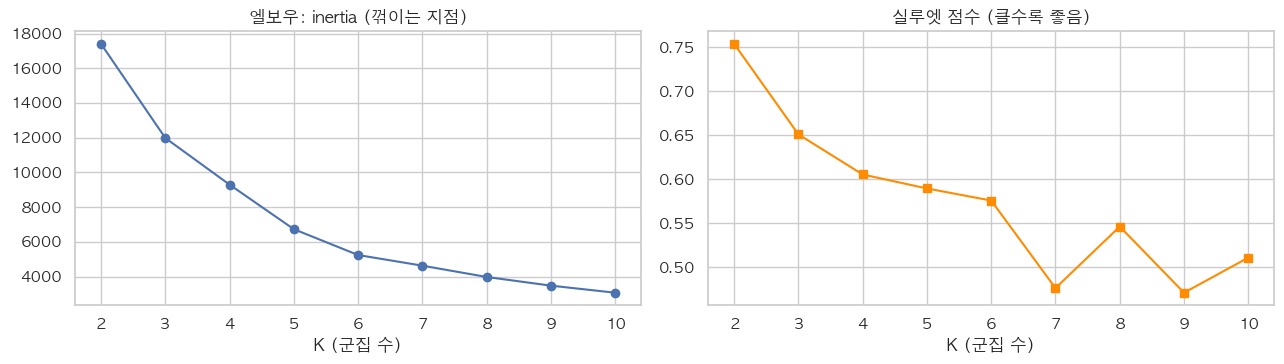

실루엣 최고 K: 2 | 점수: [0.754, 0.651, 0.605, 0.589, 0.576, 0.476, 0.546, 0.471, 0.511]


In [7]:
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertias, silhouettes = [], []
for k in ks:
  km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(loc_train)
  inertias.append(km.inertia_)
  # 실루엣은 모든 점 쌍의 거리를 쓰므로 1만 개 넘으면 느리다 -> 3,000개 표본으로 계산
  silhouettes.append(silhouette_score(loc_train, km.labels_, sample_size=3000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(list(ks), inertias, "o-")
axes[0].set_title("엘보우: inertia (꺾이는 지점)")
axes[1].plot(list(ks), silhouettes, "s-", color="darkorange")
axes[1].set_title("실루엣 점수 (클수록 좋음)")
for ax in axes:
  ax.set_xlabel("K (군집 수)")
plt.tight_layout()
plt.show()
print("실루엣 최고 K:", list(ks)[int(np.argmax(silhouettes))], "| 점수:", np.round(silhouettes, 3).tolist())

엘보우와 실루엣이 항상 같은 답을 주지는 않습니다. 두 지표는 **후보를 좁히는 도구** 이고, 최종 K 는 "군집을 해석하고 활용하기 좋은가" 로 정합니다.

### 1.2.3 K-Means 는 스케일링이 필수

K-Means 는 **거리** 로 묶기 때문에 단위가 큰 변수가 결과를 지배합니다. `소득중앙값`(0.5~15)과 `인구`(3~35,000)로 묶어 봅니다.

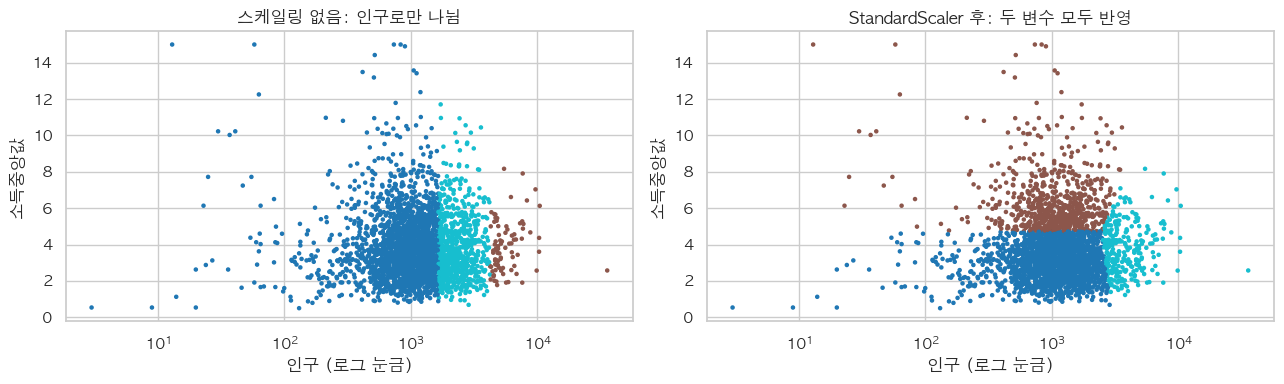

In [8]:
pair = Xr_train[["소득중앙값", "인구"]]
km_raw = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(pair)
km_scaled = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(StandardScaler().fit_transform(pair))

sample = np.random.default_rng(0).choice(len(pair), 3000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, km) in zip(axes, [("스케일링 없음: 인구로만 나뉨", km_raw), ("StandardScaler 후: 두 변수 모두 반영", km_scaled)]):
  ax.scatter(pair["인구"].values[sample], pair["소득중앙값"].values[sample], c=km.labels_[sample], cmap="tab10", s=5)
  ax.set_xscale("log")
  ax.set_xlabel("인구 (로그 눈금)")
  ax.set_ylabel("소득중앙값")
  ax.set_title(name)
plt.tight_layout()
plt.show()

왼쪽은 경계가 **세로줄** (인구 기준)로만 생겼습니다. 숫자가 큰 인구가 거리를 독차지했기 때문입니다. 오른쪽은 소득도 반영되었습니다.

### 1.3 타이타닉 승객 세분화 (생존 정보 없이)

생존 여부를 **빼고** 승객 특성만으로 묶은 뒤, 나중에 군집별 생존율을 확인합니다. "고객 세분화 → 군집별 이탈률 비교" 와 같은 흐름입니다.

In [9]:
seg_cols = ["객실등급", "성별", "나이", "운임", "가족수"]
seg_scaler = StandardScaler()
seg_X = seg_scaler.fit_transform(titanic_clean[seg_cols])

km_t = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(seg_X)
segments = titanic_clean[seg_cols + ["생존"]].assign(군집=km_t.labels_)
seg_profile = segments.groupby("군집").agg(
  인원=("생존", "size"), 객실등급=("객실등급", "mean"), 여성비율=("성별", "mean"),
  나이=("나이", "mean"), 운임=("운임", "median"), 가족수=("가족수", "mean"), 생존율=("생존", "mean"),
).round(2)
seg_profile.sort_values("생존율", ascending=False)

,인원,객실등급,여성비율,나이,운임,가족수,생존율
군집,,,,,,,
3,193,2.59,1.00,25.89,13.00,1.87,0.72
2,214,1.01,0.43,37.30,62.67,1.80,0.63
0,58,2.97,0.50,16.39,31.28,6.69,0.16
1,426,2.74,0.00,28.72,8.05,1.32,0.14


학습에 생존 여부를 전혀 쓰지 않았는데도 군집마다 생존율이 크게 다릅니다. 표를 보고 각 군집에 이름을 붙여 보세요 (예: "1등석 부유층", "3등석 남성 단독 승객", "대가족"). 이것이 비지도학습 결과를 **사람이 해석** 하는 과정입니다.

### 1.4 군집 결과를 지도학습에 활용하기

선형회귀는 위도·경도를 "직선" 으로만 쓸 수 있어 위치 정보를 잘 활용하지 못했습니다 (6회차). 위치 군집 번호를 **원-핫 변수로 추가** 하면 "이 구역은 어느 권역인가" 를 선형회귀도 쓸 수 있습니다.

> KMeans 도 전처리 단계이므로 **train 에만 fit**, test 는 `predict` 로 군집을 배정합니다.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import make_pipeline


def add_location_cluster(X: pd.DataFrame, km: KMeans) -> pd.DataFrame:
  '''위치 군집 번호를 원-핫 컬럼으로 추가 (군집 수가 같도록 모든 번호를 미리 범주로 지정)'''
  cluster = pd.Categorical(km.predict(X[["위도", "경도"]]), categories=range(km.n_clusters))
  dummies = pd.get_dummies(cluster, prefix="권역", drop_first=True, dtype=int).set_index(X.index)
  return pd.concat([X, dummies], axis=1)


rows = []
base = make_pipeline(StandardScaler(), LinearRegression()).fit(Xr_train, yr_train)
rows.append({"모델": "선형회귀 (기존 변수)", "test R2": r2_score(yr_test, base.predict(Xr_test))})
for k in [6, 12, 24]:
  km_loc = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xr_train[["위도", "경도"]])   # train 에만 fit
  Xtr_k, Xte_k = add_location_cluster(Xr_train, km_loc), add_location_cluster(Xr_test, km_loc)
  m = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr_k, yr_train)
  rows.append({"모델": f"선형회귀 + 위치 군집 {k}개", "test R2": r2_score(yr_test, m.predict(Xte_k))})
pd.DataFrame(rows).set_index("모델").round(4)

,test R2
모델,
선형회귀 (기존 변수),0.6696
선형회귀 + 위치 군집 6개,0.6787
선형회귀 + 위치 군집 12개,0.6846
선형회귀 + 위치 군집 24개,0.7037


같은 선형회귀인데 군집 변수만 추가해서 R² 가 올라갔습니다. 군집이 잘게 나뉠수록 위치 정보를 더 세밀하게 전달합니다. 비지도학습이 **특성 공학(feature engineering)** 도구로 쓰인 예입니다.

### 1.5 계층적 군집 (참고)

K 를 미리 정하지 않고, 가장 가까운 것끼리 **차례로 합쳐 가며 나무(덴드로그램)** 를 만듭니다. 나무를 원하는 높이에서 자르면 군집이 됩니다. 데이터가 많으면 느려서 수백 개 이하에 씁니다.

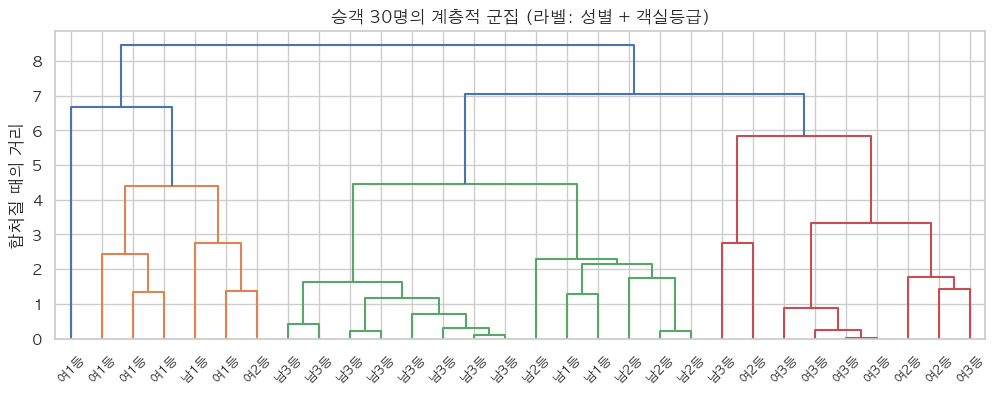

In [11]:
from scipy.cluster.hierarchy import linkage, dendrogram

few = titanic_clean.sample(30, random_state=1)
Z = linkage(StandardScaler().fit_transform(few[seg_cols]), method="ward")

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, labels=[f"{'여' if s else '남'}{int(c)}등" for s, c in zip(few["성별"], few["객실등급"])], ax=ax, leaf_font_size=9)
ax.set_title("승객 30명의 계층적 군집 (라벨: 성별 + 객실등급)")
ax.set_ylabel("합쳐질 때의 거리")
plt.show()

아래쪽에서 먼저 합쳐진 승객끼리 비슷합니다. 같은 성별·등급의 승객이 가까이 모이는 것을 볼 수 있습니다.

## 1.6 PCA (주성분 분석, 차원 축소)

### 한 줄 정의
여러 변수를 **정보(분산)를 최대한 보존하는 소수의 새 축(주성분)** 으로 압축하는 방법.

### 직관적 설명
3차원 물체에 손전등을 비춰 벽에 그림자를 만드는 것과 같습니다. 어느 방향에서 비추느냐에 따라 그림자가 물체를 잘 보여 주기도, 납작하게 뭉개기도 합니다. PCA 는 **그림자가 가장 넓게 퍼지는(정보가 가장 많이 남는) 방향** 을 찾아 그쪽으로 투영합니다.

| 쓰임 | 설명 |
|------|------|
| **시각화** | 변수 11개를 2개로 줄여 산점도로 그리기 |
| **다중공선성 제거** | 서로 상관이 높은 변수들(총방수·총침실수·가구수)을 하나의 축으로 합치기 |
| **계산량 감소** | 변수가 수백 개일 때 모델 학습 속도 향상 |

> PCA 도 **거리·분산 기반** 이라 **스케일링을 먼저** 해야 합니다.

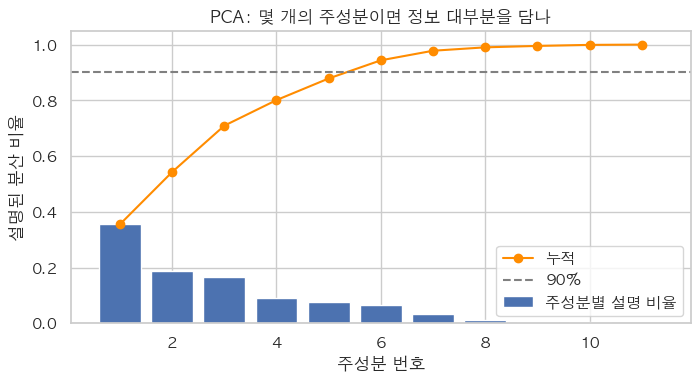

누적 설명 비율: [0.355, 0.543, 0.709, 0.801, 0.878, 0.944, 0.978, 0.99, 0.995, 0.999, 1.0]
90% 이상을 담는 최소 주성분 수: 6 / 11


In [12]:
from sklearn.decomposition import PCA

pca_scaler = StandardScaler()
Xr_train_s = pca_scaler.fit_transform(Xr_train)

pca_full = PCA(random_state=RANDOM_STATE).fit(Xr_train_s)
ratio = pca_full.explained_variance_ratio_
cum = np.cumsum(ratio)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(range(1, len(ratio) + 1), ratio, label="주성분별 설명 비율")
ax.plot(range(1, len(ratio) + 1), cum, "o-", color="darkorange", label="누적")
ax.axhline(0.9, color="gray", linestyle="--", label="90%")
ax.set_xlabel("주성분 번호")
ax.set_ylabel("설명된 분산 비율")
ax.set_title("PCA: 몇 개의 주성분이면 정보 대부분을 담나")
ax.legend()
plt.show()
print("누적 설명 비율:", np.round(cum, 3).tolist())
print("90% 이상을 담는 최소 주성분 수:", int(np.argmax(cum >= 0.9)) + 1, "/", len(ratio))

In [13]:
# 주성분이 원래 변수의 어떤 조합인지 (loadings): 절댓값이 클수록 그 주성분에 크게 기여
loadings = pd.DataFrame(pca_full.components_[:3].T, index=Xr_train.columns, columns=["PC1", "PC2", "PC3"]).round(2)
loadings.sort_values("PC1", key=abs, ascending=False)

,PC1,PC2,PC3
총침실수,0.49,0.02,-0.10
가구수,0.49,0.03,-0.11
총방수,0.48,-0.13,0.01
인구,0.47,0.04,-0.07
주택연식,-0.22,0.12,-0.14
경도,0.08,0.44,0.54
위도,-0.07,-0.44,-0.54
소득중앙값,0.04,-0.41,0.42
가구당방수,0.01,-0.39,0.27
침실비율,-0.01,0.50,-0.35


- **PC1** 은 총방수·총침실수·인구·가구수가 크게 기여합니다. "구역의 크기" 를 하나로 압축한 축입니다. 4회차 EDA 에서 본 상관 0.9 이상 변수들이 하나로 합쳐진 것입니다.
- **PC2** 는 침실비율·경도(+)와 위도·소득중앙값·가구당방수(-)가 섞여 있습니다. 이처럼 뒤쪽 주성분은 **한 단어로 이름 붙이기 어려운 경우가 많습니다.** PCA 의 단점 중 하나가 해석이 어렵다는 점입니다.

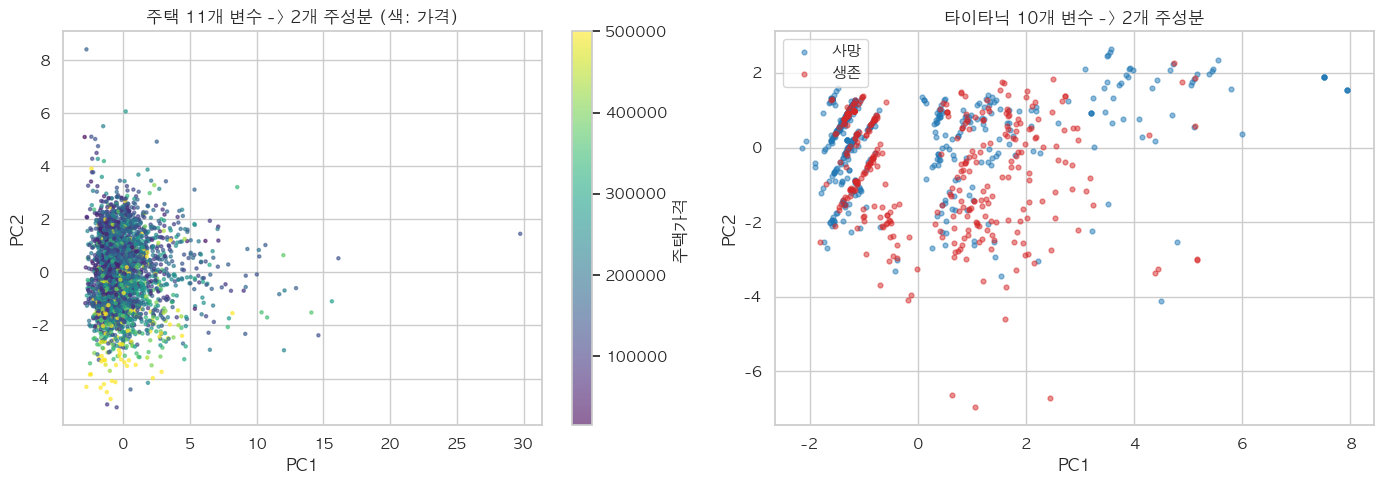

In [14]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
Z_r = pca2.fit_transform(Xr_train_s)

Xc_s = StandardScaler().fit_transform(Xc)
Z_c = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xc_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(Z_r[sample, 0], Z_r[sample, 1], c=yr_train.values[sample], cmap="viridis", s=5, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label="주택가격")
axes[0].set_title("주택 11개 변수 -> 2개 주성분 (색: 가격)")
for v, name, color in [(0, "사망", "tab:blue"), (1, "생존", "tab:red")]:
  axes[1].scatter(Z_c[yc == v, 0], Z_c[yc == v, 1], s=12, alpha=0.5, label=name, color=color)
axes[1].set_title("타이타닉 10개 변수 -> 2개 주성분")
axes[1].legend()
for ax in axes:
  ax.set_xlabel("PC1")
  ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

정답(가격, 생존)을 쓰지 않고 압축했지만 2차원 그림에서 색이 어느 정도 나뉘어 보입니다. 변수 수십 개짜리 데이터의 **전체 모양을 한눈에** 보는 데 PCA 가 자주 쓰입니다.

In [15]:
# PCA 로 압축한 변수로 학습하면? 주성분 수별 선형회귀 test R²
rows = []
for n in [2, 4, 6, 8, len(Xr_train.columns)]:
  m = make_pipeline(StandardScaler(), PCA(n_components=n, random_state=RANDOM_STATE), LinearRegression()).fit(Xr_train, yr_train)
  rows.append({"주성분 수": n, "누적 설명 비율": round(cum[n - 1], 3), "test R2": round(r2_score(yr_test, m.predict(Xr_test)), 4)})
pd.DataFrame(rows).set_index("주성분 수")

,누적 설명 비율,test R2
주성분 수,,
2,0.543,0.1007
4,0.801,0.2333
6,0.944,0.4093
8,0.990,0.6251
11,1.000,0.6696


주성분을 줄이자 성능이 **크게** 떨어졌습니다. 주성분 6개가 분산의 94% 를 담는데도 R² 는 0.67 → 0.41 입니다. 이유는 PCA 가 **정답(y)을 보지 않고** "입력이 많이 퍼진 방향" 만 고르기 때문입니다. 가장 퍼진 방향(구역 크기)은 가격과 별 관련이 없고, 가격에 중요한 소득중앙값 정보는 뒤쪽 주성분에 흩어져 있습니다.

> **교훈**: "설명된 분산이 크다" 와 "예측에 유용하다" 는 다른 이야기입니다. PCA 는 시각화나 변수가 아주 많을 때의 압축에 쓰고, 예측 성능이 목적이면 **압축 전후를 교차검증으로 비교** 한 뒤 결정합니다. 이 데이터처럼 변수가 11개뿐이면 압축할 이유가 없습니다.

### 📝 시험 출제 포인트 (Part 1)

- "`KMeans(n_clusters=3, random_state=42)` 로 군집화하고 군집 번호를 `cluster` 컬럼에 저장" → `df["cluster"] = km.fit_predict(X_scaled)`
- "엘보우 기법으로 적절한 K 를 찾으시오" → K 별 `inertia_` 그래프
- "군집별 평균을 구하시오" → `groupby("cluster").mean()`
- "PCA 로 2개 주성분을 구하고 설명된 분산 비율을 출력" → `PCA(n_components=2)`, `explained_variance_ratio_`

### ⚠️ 자주 하는 실수 (Part 1)

- **스케일링 없이 K-Means / PCA**: 큰 단위 변수가 결과를 독차지합니다.
- **`fit` 에 y 를 넣음**: 비지도학습은 `fit(X)` 만. y 를 넣어도 무시되거나 의미 없음.
- **군집 번호를 크기·순서로 해석**: 군집 0 과 3 은 이름표일 뿐 "3 이 더 크다" 는 뜻이 아닙니다. 모델 입력으로 쓸 때는 **원-핫** 으로.
- **군집 번호가 실행마다 바뀜**: `random_state` 를 고정하지 않으면 같은 무리라도 번호가 달라집니다.

---
# Part 2. 모델 성능 향상시키기

## 2.1 한 번의 분할은 믿기 어렵다

지금까지는 `train_test_split` 한 번으로 평가했습니다. **분할만 바꿔도 점수가 얼마나 흔들리는지** 확인해 봅니다.

같은 모델, 분할만 30번 바꿨을 때 test 정확도: 최저 0.777 ~ 최고 0.838 (평균 0.804)


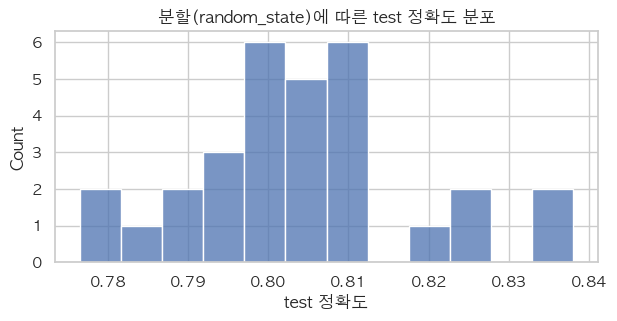

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

scores = []
for seed in range(30):
  Xa, Xb, ya, yb = train_test_split(Xc, yc, test_size=0.2, random_state=seed, stratify=yc)
  m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xa, ya)
  scores.append(accuracy_score(yb, m.predict(Xb)))

print(f"같은 모델, 분할만 30번 바꿨을 때 test 정확도: 최저 {min(scores):.3f} ~ 최고 {max(scores):.3f} (평균 {np.mean(scores):.3f})")
fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(scores, bins=12, ax=ax)
ax.set_title("분할(random_state)에 따른 test 정확도 분포")
ax.set_xlabel("test 정확도")
plt.show()

같은 모델인데 **운에 따라 수 %p 씩** 차이가 납니다. 6·7회차에서 "test 179명이라 작은 차이로 순위를 단정하지 말라" 고 한 이유입니다. 그래서 **여러 번 나눠서 평균** 을 냅니다.

## 2.2 교차검증 (Cross Validation)

### 한 줄 정의
데이터를 **K 개 조각(fold)** 으로 나누어, 조각마다 한 번씩 검증용으로 쓰고 나머지로 학습해 **K 개 점수의 평균** 으로 평가하는 방법.

```
5-fold 교차검증
1회차: [검증][학습][학습][학습][학습]  → 점수1
2회차: [학습][검증][학습][학습][학습]  → 점수2
3회차: [학습][학습][검증][학습][학습]  → 점수3
4회차: [학습][학습][학습][검증][학습]  → 점수4
5회차: [학습][학습][학습][학습][검증]  → 점수5      → 평균 ± 표준편차
```

| 도구 | 용도 |
|------|------|
| `KFold(n_splits=5, shuffle=True)` | 회귀용 기본 분할 |
| `StratifiedKFold(n_splits=5, shuffle=True)` | **분류용**: fold 마다 클래스 비율 유지 |
| `cross_val_score(model, X, y, cv=5, scoring=...)` | 점수 배열 하나 반환 |
| `cross_validate(..., scoring=[...], return_train_score=True)` | 여러 지표 + train 점수까지 |

> 교차검증은 **train 데이터 안에서만** 합니다. test 는 마지막 확인용으로 아껴 둡니다.

In [17]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {
  "로지스틱 회귀": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
  "랜덤포레스트": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1),
}
for name, m in models.items():
  s = cross_val_score(m, Xc_train, yc_train, cv=skf, scoring="accuracy")
  print(f"{name:<8} fold 별 {np.round(s, 3)} -> 평균 {s.mean():.4f} ± {s.std():.4f}")

로지스틱 회귀  fold 별 [0.804 0.79  0.803 0.775 0.817] -> 평균 0.7978 ± 0.0143


랜덤포레스트   fold 별 [0.839 0.783 0.859 0.803 0.803] -> 평균 0.8174 ± 0.0276


In [18]:
# 여러 지표 + train 점수를 한 번에: 과적합까지 함께 진단
cv_res = cross_validate(models["랜덤포레스트"], Xc_train, yc_train, cv=skf,
                        scoring=["accuracy", "f1", "roc_auc"], return_train_score=True)
pd.DataFrame(cv_res).drop(columns=["fit_time", "score_time"]).agg(["mean", "std"]).round(4)

,test_accuracy,train_accuracy,test_f1,train_f1,test_roc_auc,train_roc_auc
mean,0.8174,0.894,0.7411,0.8502,0.8789,0.9452
std,0.0309,0.007,0.0425,0.0101,0.0218,0.0047


`scoring` 에 쓸 수 있는 대표 이름:

| 분류 | 회귀 |
|------|------|
| `"accuracy"`, `"f1"`, `"precision"`, `"recall"`, `"roc_auc"` | `"r2"`, `"neg_mean_squared_error"`, `"neg_root_mean_squared_error"`, `"neg_mean_absolute_error"` |

> 회귀 오차 지표 앞의 **`neg_`** 는 "클수록 좋다" 로 통일하려고 부호를 뒤집은 것입니다. 결과가 음수로 나오므로 `-` 를 붙여 해석합니다.

In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rmse = -cross_val_score(HistGradientBoostingRegressor(random_state=RANDOM_STATE), Xr_train, yr_train,
                        cv=kf, scoring="neg_root_mean_squared_error")
print("주택 HistGB 5-fold RMSE:", np.round(rmse).astype(int).tolist(), f"-> 평균 {rmse.mean():,.0f}")

주택 HistGB 5-fold RMSE: [46850, 49799, 45198, 45974, 47496] -> 평균 47,063


## 2.3 Pipeline: 전처리를 모델에 묶어 정보 누출 막기

교차검증할 때 스케일러·결측 대체를 **전체 train 에 먼저 fit** 하면, 검증 fold 의 정보가 학습 fold 의 전처리에 섞입니다 (4회차의 정보 누출과 같은 문제). **Pipeline 으로 전처리 + 모델을 하나로 묶으면** 교차검증의 매 fold 마다 전처리도 학습 fold 에만 fit 됩니다.

`ColumnTransformer` 는 **컬럼마다 다른 전처리** (수치형: 결측 대체 + 스케일링, 범주형: 결측 대체 + 원-핫) 를 한 번에 적용합니다. 이제 **원본 데이터를 그대로** 넣을 수 있습니다.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 원본에 가까운 타이타닉 (결측·문자열 그대로)
raw = titanic.drop(columns=["승객ID", "이름", "티켓번호", "객실번호"])
raw["가족수"] = raw["동반형제배우자"] + raw["동반부모자녀"] + 1
X_raw = raw.drop(columns=["생존"])
y_raw = raw["생존"]
Xraw_train, Xraw_test, yraw_train, yraw_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE, stratify=y_raw)

num_cols = ["객실등급", "나이", "동반형제배우자", "동반부모자녀", "운임", "가족수"]
cat_cols = ["성별", "탑승항구"]

preprocess = ColumnTransformer([
  ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_cols),
  ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))]), cat_cols),
])
pipe = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=1000))])

print("결측이 있는 원본 그대로:", Xraw_train.isnull().sum()[lambda s: s > 0].to_dict())
s = cross_val_score(pipe, Xraw_train, yraw_train, cv=skf, scoring="accuracy")
print(f"Pipeline 5-fold 정확도: {s.mean():.4f} ± {s.std():.4f}")
pipe

결측이 있는 원본 그대로: {'나이': 137, '탑승항구': 2}
Pipeline 5-fold 정확도: 0.7949 ± 0.0273


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['객실등급', '나이', '동반형제배우자',
                                                   '동반부모자녀', '운임', '가족수']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['성별', '탑승항구'])])),
                ('model', LogisticRegression(max_iter=1000))])

마지막 줄의 `pipe` 를 출력하면 파이프라인 구조가 그림으로 보입니다. Pipeline 안의 단계는 **`이름__파라미터`** (밑줄 두 개)로 접근합니다. 예: `model__C`, `prep__num__impute__strategy`. 2.4 의 튜닝에서 이 이름을 씁니다.

## 2.4 하이퍼파라미터 튜닝: GridSearchCV

### 한 줄 정의
후보 하이퍼파라미터의 **모든 조합** 을 교차검증으로 평가해 가장 좋은 조합을 고르는 도구.

```
max_depth = [4, 6, 8, None]       ×  min_samples_leaf = [1, 3, 5]  =  12 조합
12 조합 × 5-fold = 60 번 학습 → 평균 점수가 가장 높은 조합 선택 → 그 조합으로 train 전체에 다시 학습 (refit)
```

In [21]:
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))])
param_grid = {
  "model__max_depth": [4, 6, 8, None],
  "model__min_samples_leaf": [1, 3, 5],
}
grid = GridSearchCV(rf_pipe, param_grid, cv=skf, scoring="roc_auc", n_jobs=-1)

start = time.time()
grid.fit(Xraw_train, yraw_train)
print(f"튜닝 시간: {time.time() - start:.1f}초 ({len(grid.cv_results_['params'])} 조합 × 5 fold)")
print("최적 조합:", grid.best_params_)
print("최적 교차검증 AUC:", round(grid.best_score_, 4))

튜닝 시간: 5.9초 (12 조합 × 5 fold)
최적 조합: {'model__max_depth': None, 'model__min_samples_leaf': 3}
최적 교차검증 AUC: 0.8813


In [22]:
# 모든 조합의 결과 표
res = grid.cv_results_
cv_table = pd.DataFrame({
  "max_depth": [str(p["model__max_depth"]) for p in res["params"]],      # None(제한 없음)이 NaN 으로 보이지 않게 문자열로
  "min_samples_leaf": [p["model__min_samples_leaf"] for p in res["params"]],
  "평균 AUC": res["mean_test_score"],
  "표준편차": res["std_test_score"],
  "순위": res["rank_test_score"],
})
cv_table.sort_values("순위").head(6).round(4)

,max_depth,min_samples_leaf,평균 AUC,표준편차,순위
10,None,3,0.8813,0.0161,1
11,None,5,0.8798,0.0221,2
8,8,5,0.8792,0.0212,3
5,6,5,0.8774,0.0209,4
3,6,1,0.8769,0.0189,5
7,8,3,0.8758,0.0164,6


In [23]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report

best_rf = grid.best_estimator_            # 최적 조합으로 train 전체에 다시 학습된 Pipeline
proba = best_rf.predict_proba(Xraw_test)[:, 1]
pred = best_rf.predict(Xraw_test)
print(f"test 정확도 {accuracy_score(yraw_test, pred):.4f} | F1 {f1_score(yraw_test, pred):.4f} | AUC {roc_auc_score(yraw_test, proba):.4f}")

test 정확도 0.8045 | F1 0.7154 | AUC 0.8335


> **test 점수는 교차검증 점수보다 낮거나 높을 수 있습니다.** 중요한 것은 하이퍼파라미터를 **test 를 보지 않고** 골랐다는 점입니다. 6회차에서 test 로 깊이를 골랐던 방식은 test 를 엿본 것이라 점수가 낙관적으로 나옵니다.

### 2.4.1 파이프라인 없이 GridSearchCV 쓰기

위에서는 원본 데이터(결측·문자열 포함)를 넣으려고 Pipeline 을 썼습니다. 하지만 **데이터가 이미 전처리되어 있고, 모델이 스케일링을 필요로 하지 않으면** 모델을 GridSearchCV 에 바로 넣어도 됩니다. AICE 시험 문항은 대부분 이 형태입니다. 앞 문항에서 전처리를 끝낸 `X_train` 으로 튜닝합니다.

| 항목 | Pipeline 사용 (2.4) | Pipeline 없이 (2.4.1) |
|------|------|------|
| 넣는 데이터 | 원본 (결측·문자열 그대로) | **전처리가 끝난** 데이터 |
| GridSearchCV 에 넣는 것 | `Pipeline([...])` | **모델 객체 그대로** |
| 파라미터 이름 | `"model__max_depth"` (단계 이름 + 밑줄 2개) | **`"max_depth"`** (그대로) |
| `best_estimator_` | 전처리 + 모델이 묶인 Pipeline | 모델 하나 |

#### 예 1: 랜덤포레스트 (스케일링이 필요 없는 모델)

0장에서 전처리를 끝낸 `Xc_train` (결측 대체·성별 0/1·원-핫 완료)을 그대로 씁니다.

In [24]:
param_grid_plain = {                      # 파라미터 이름에 접두사가 없다
  "max_depth": [4, 6, 8, None],
  "min_samples_leaf": [1, 3, 5],
}
grid_plain = GridSearchCV(
  RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),   # 모델을 그대로 넣는다
  param_grid_plain, cv=skf, scoring="roc_auc", n_jobs=-1,
)
grid_plain.fit(Xc_train, yc_train)

print("최적 조합:", grid_plain.best_params_)
print("최적 교차검증 AUC:", round(grid_plain.best_score_, 4))

best_plain = grid_plain.best_estimator_     # 최적 조합으로 Xc_train 전체에 다시 학습된 RandomForestClassifier
proba = best_plain.predict_proba(Xc_test)[:, 1]
pred = best_plain.predict(Xc_test)
print(f"test 정확도 {accuracy_score(yc_test, pred):.4f} | F1 {f1_score(yc_test, pred):.4f} | AUC {roc_auc_score(yc_test, proba):.4f}")
print("best_estimator_ 의 종류:", type(best_plain).__name__)

최적 조합: {'max_depth': None, 'min_samples_leaf': 5}
최적 교차검증 AUC: 0.8821
test 정확도 0.8045 | F1 0.7154 | AUC 0.8361
best_estimator_ 의 종류: RandomForestClassifier


In [25]:
# 결과 표도 같은 방법으로 본다. 파라미터 열 이름이 param_max_depth 처럼 접두사 없이 나온다
res_plain = grid_plain.cv_results_
pd.DataFrame({
  "max_depth": [str(p["max_depth"]) for p in res_plain["params"]],
  "min_samples_leaf": [p["min_samples_leaf"] for p in res_plain["params"]],
  "평균 AUC": res_plain["mean_test_score"].round(4),
  "순위": res_plain["rank_test_score"],
}).sort_values("순위").head(5)

,max_depth,min_samples_leaf,평균 AUC,순위
11,None,5,0.8821,1
10,None,3,0.8819,2
4,6,3,0.8798,3
8,8,5,0.8798,4
7,8,3,0.8796,5


#### 예 2: 로지스틱 회귀 (스케일링이 필요한 모델)

스케일링이 필요한 모델은 **먼저 스케일링한 데이터** 를 GridSearchCV 에 넣습니다. 4회차에서 배운 대로 스케일러는 train 에만 fit 합니다.

`C` 는 로지스틱 회귀의 **규제 세기의 역수** 입니다. 작을수록 계수를 강하게 눌러(단순한 모델) 과적합을 줄이고, 클수록 학습 데이터에 더 맞춥니다.

In [26]:
scaler_g = StandardScaler()
Xc_train_s = scaler_g.fit_transform(Xc_train)      # train 에 fit
Xc_test_s = scaler_g.transform(Xc_test)            # test 는 transform 만

grid_lr = GridSearchCV(
  LogisticRegression(max_iter=1000),
  {"C": [0.01, 0.1, 1, 10]},
  cv=skf, scoring="roc_auc",
)
grid_lr.fit(Xc_train_s, yc_train)
print("[파이프라인 없이] 최적 C:", grid_lr.best_params_, "| 교차검증 AUC:", round(grid_lr.best_score_, 4),
      "| test AUC:", round(roc_auc_score(yc_test, grid_lr.predict_proba(Xc_test_s)[:, 1]), 4))

# 같은 튜닝을 Pipeline 으로: 파라미터 이름에 단계 이름(logisticregression__)이 붙는다
grid_lr_pipe = GridSearchCV(
  make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
  {"logisticregression__C": [0.01, 0.1, 1, 10]},
  cv=skf, scoring="roc_auc",
)
grid_lr_pipe.fit(Xc_train, yc_train)               # 스케일링 전 데이터를 넣는다
print("[Pipeline 사용 ] 최적 C:", grid_lr_pipe.best_params_, "| 교차검증 AUC:", round(grid_lr_pipe.best_score_, 4),
      "| test AUC:", round(roc_auc_score(yc_test, grid_lr_pipe.predict_proba(Xc_test)[:, 1]), 4))

[파이프라인 없이] 최적 C: {'C': 0.1} | 교차검증 AUC: 0.8565 | test AUC: 0.8486


[Pipeline 사용 ] 최적 C: {'logisticregression__C': 0.1} | 교차검증 AUC: 0.8566 | test AUC: 0.8486


두 방식의 결과가 거의 같습니다. 차이가 생긴다면 이유는 하나입니다.

- **파이프라인 없이**: 스케일러를 `Xc_train` **전체** 에 먼저 fit 했습니다. 그래서 교차검증의 검증 조각 정보도 스케일러의 평균·표준편차에 조금 섞여 있습니다 (약한 정보 누출). 교차검증 점수가 아주 조금 낙관적으로 나올 수 있습니다.
- **Pipeline 사용**: 교차검증의 매 조각마다 스케일러를 학습 조각에만 다시 fit 하므로 누출이 없습니다.

> 팁: 어느 쪽을 쓸까
> - 시험 문제가 `X_train_scaled` 처럼 **스케일링 결과 변수를 먼저 만들게** 하거나 모델만 지정하면 → **파이프라인 없이** (예 1, 예 2 방식). 이 데이터처럼 행이 수백 개 이상이면 누출의 영향은 대개 무시할 만큼 작습니다.
> - 원본 데이터를 넣고 싶거나, 결측 대체·인코딩까지 교차검증 안에서 정확하게 하고 싶을 때 → **Pipeline** (2.4 방식).
> - 트리 계열(결정트리·랜덤포레스트·부스팅)은 스케일링이 필요 없으므로 전처리만 끝났다면 파이프라인 없이 쓰는 것이 가장 간단합니다.

> 주의: 파이프라인 없이 쓸 때 파라미터 이름에 `model__` 같은 접두사를 붙이면 `ValueError: Invalid parameter 'model' for estimator` 가 납니다. 반대로 Pipeline 에 접두사 없이 `max_depth` 를 넣어도 같은 오류가 납니다. **GridSearchCV 에 넣은 것이 무엇인지** 에 맞춰 이름을 씁니다.

## 2.5 RandomizedSearchCV: 조합이 많을 때

GridSearch 는 조합이 곱으로 늘어납니다 (5개 파라미터 × 5개 후보 = 3,125 조합). **RandomizedSearchCV** 는 범위에서 **정해진 횟수(`n_iter`)만 무작위로** 뽑아 시도합니다. 같은 시간에 더 넓은 범위를 탐색할 수 있습니다.

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

param_dist = {
  "learning_rate": loguniform(0.02, 0.3),     # 0.02~0.3 를 로그 눈금으로 고르게 (작은 값도 충분히 시도)
  "max_iter": randint(200, 800),               # 정수 200~799
  "max_leaf_nodes": randint(15, 63),
  "min_samples_leaf": randint(10, 60),
  "l2_regularization": uniform(0, 1.0),        # 0~1 실수
}
rand = RandomizedSearchCV(
  HistGradientBoostingRegressor(random_state=RANDOM_STATE), param_dist,
  n_iter=12, cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
  scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1,
)
start = time.time()
rand.fit(Xr_train, yr_train)
print(f"튜닝 시간: {time.time() - start:.1f}초 (12 조합 × 3 fold)")
print("최적 조합:", {k: (round(v, 4) if isinstance(v, float) else v) for k, v in rand.best_params_.items()})
print(f"교차검증 RMSE: {-rand.best_score_:,.0f}")

default_hgb = HistGradientBoostingRegressor(random_state=RANDOM_STATE).fit(Xr_train, yr_train)
for name, m in [("기본값", default_hgb), ("튜닝 후", rand.best_estimator_)]:
  p = m.predict(Xr_test)
  print(f"{name:<5} test RMSE {np.sqrt(mean_squared_error(yr_test, p)):,.0f} | R² {r2_score(yr_test, p):.4f}")

튜닝 시간: 15.5초 (12 조합 × 3 fold)
최적 조합: {'l2_regularization': 0.1734, 'learning_rate': 0.0577, 'max_iter': 761, 'max_leaf_nodes': 54, 'min_samples_leaf': 13}
교차검증 RMSE: 46,267


기본값   test RMSE 46,934 | R² 0.8401
튜닝 후  test RMSE 45,338 | R² 0.8508


| 방법 | 탐색 방식 | 장점 | 단점 |
|------|------|------|------|
| GridSearchCV | 모든 조합 | 빠짐없이 확인, 결과 재현 쉬움 | 조합이 많으면 매우 느림 |
| RandomizedSearchCV | `n_iter` 개 무작위 | 넓은 범위를 빠르게 | 최적을 놓칠 수 있음 |

> 실무 순서: **Randomized 로 넓게 → 좋은 근처를 Grid 로 촘촘하게.**

## 2.6 불균형 데이터 다루기

타이타닉은 생존 38% 로 약한 불균형입니다. 소수 클래스(생존)를 더 잘 잡고 싶을 때 쓰는 방법을 비교합니다.

| 방법 | 코드 | 원리 |
|------|------|------|
| **class_weight** | `LogisticRegression(class_weight="balanced")` | 소수 클래스를 틀리면 벌점을 크게 |
| **임계값 조정** | `(proba >= 0.4)` | 5회차: 확률 기준을 낮춰 양성을 더 많이 |
| **오버샘플링 (SMOTE)** | `imblearn.over_sampling.SMOTE` | 소수 클래스의 가짜 샘플을 만들어 늘림 (**train 에만**) |
| 언더샘플링 | `RandomUnderSampler` | 다수 클래스를 줄임 (데이터 손실) |

In [28]:
from sklearn.metrics import recall_score, precision_score

rows = []
for name, model in [
  ("기본", LogisticRegression(max_iter=1000)),
  ("class_weight='balanced'", LogisticRegression(max_iter=1000, class_weight="balanced")),
]:
  p = Pipeline([("prep", preprocess), ("model", model)]).fit(Xraw_train, yraw_train)
  pr = p.predict(Xraw_test)
  rows.append({"방법": name, "정확도": accuracy_score(yraw_test, pr), "정밀도": precision_score(yraw_test, pr),
               "재현율": recall_score(yraw_test, pr), "F1": f1_score(yraw_test, pr)})

proba_lr = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=1000))]).fit(Xraw_train, yraw_train).predict_proba(Xraw_test)[:, 1]
pr = (proba_lr >= 0.4).astype(int)
rows.append({"방법": "임계값 0.4", "정확도": accuracy_score(yraw_test, pr), "정밀도": precision_score(yraw_test, pr),
             "재현율": recall_score(yraw_test, pr), "F1": f1_score(yraw_test, pr)})
pd.DataFrame(rows).set_index("방법").round(4)

,정확도,정밀도,재현율,F1
방법,,,,
기본,0.8045,0.7931,0.6667,0.7244
class_weight='balanced',0.8045,0.7297,0.7826,0.7552
임계값 0.4,0.8101,0.7397,0.7826,0.7606


In [29]:
try:
  from imblearn.over_sampling import SMOTE
  from imblearn.pipeline import Pipeline as ImbPipeline     # SMOTE 를 넣을 땐 imblearn 의 Pipeline 을 써야 fold 마다 train 에만 적용된다

  smote_pipe = ImbPipeline([("prep", preprocess), ("smote", SMOTE(random_state=RANDOM_STATE)),
                            ("model", LogisticRegression(max_iter=1000))]).fit(Xraw_train, yraw_train)
  pr = smote_pipe.predict(Xraw_test)
  print(f"SMOTE: 재현율 {recall_score(yraw_test, pr):.4f} | F1 {f1_score(yraw_test, pr):.4f}")
except ImportError:
  print("imbalanced-learn 이 없습니다: pip install imbalanced-learn  (Colab 에는 기본 설치)")

imbalanced-learn 이 없습니다: pip install imbalanced-learn  (Colab 에는 기본 설치)


세 방법 모두 **재현율을 올리는 대신 정밀도를 내줍니다.** 무엇을 우선할지는 5회차의 "지표 선택" 기준(놓치면 안 되는가, 거짓 경보가 비싼가)으로 정합니다.

## 2.7 변수 선택: 순열 중요도

`feature_importances_` (6회차)는 트리 내부 계산이라 **고유값이 많은 변수를 과대평가** 하는 경향이 있습니다. **순열 중요도 (permutation importance)** 는 "그 변수의 값을 무작위로 섞었을 때 **test 점수가 얼마나 떨어지나**" 로 재므로 모델 종류와 상관없이 쓸 수 있고 더 믿을 만합니다.

In [30]:
from sklearn.inspection import permutation_importance

rf_plain = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1).fit(Xc_train, yc_train)
perm = permutation_importance(rf_plain, Xc_test, yc_test, scoring="roc_auc", n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)

imp = pd.DataFrame({
  "트리 중요도": rf_plain.feature_importances_,
  "순열 중요도(AUC 감소)": perm.importances_mean,
}, index=Xc_train.columns).sort_values("순열 중요도(AUC 감소)", ascending=False).round(4)
imp

,트리 중요도,순열 중요도(AUC 감소)
성별,0.3904,0.2035
객실등급,0.1177,0.0268
운임,0.1970,0.0260
나이,0.1318,0.0234
가족수,0.0602,0.0167
동반형제배우자,0.0302,0.0037
동반부모자녀,0.0207,0.0022
혼자탑승,0.0164,0.0018
탑승항구_S,0.0257,0.0007
탑승항구_Q,0.0097,0.0001


In [31]:
# 순열 중요도가 아주 작은 변수(섞어도 AUC 가 0.002 도 안 떨어짐)를 빼고 교차검증으로 비교
weak = imp.index[imp["순열 중요도(AUC 감소)"] < 0.002].tolist()
print("제거 후보:", weak)
for name, cols in [("전체 변수", Xc_train.columns.tolist()), ("약한 변수 제거", [c for c in Xc_train.columns if c not in weak])]:
  s = cross_val_score(RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1),
                      Xc_train[cols], yc_train, cv=skf, scoring="roc_auc")
  print(f"{name:<8} ({len(cols)}개) 교차검증 AUC {s.mean():.4f} ± {s.std():.4f}")

제거 후보: ['혼자탑승', '탑승항구_S', '탑승항구_Q']


전체 변수    (10개) 교차검증 AUC 0.8788 ± 0.0197


약한 변수 제거 (7개) 교차검증 AUC 0.8816 ± 0.0223


변수를 줄여도 성능이 비슷하면 **더 단순한 모델** 을 고릅니다. 학습이 빠르고, 새 데이터에서 덜 흔들리며, 설명하기 쉽습니다.

## 2.8 성능 향상 체크리스트

| 순서 | 할 일 | 회차 |
|:---:|------|:---:|
| 1 | **데이터부터**: 결측·이상치·인코딩이 적절한가, 정보 누출은 없는가 | 4 |
| 2 | **특성 공학**: 파생 변수(비율, 호칭, 가족수), 구간화, 군집 변수 | 4, 8 |
| 3 | **모델 바꾸기**: 선형 → 랜덤포레스트 → 부스팅 | 5, 6 |
| 4 | **교차검증으로 비교**: 한 번의 분할로 결정하지 않기 | 8 |
| 5 | **하이퍼파라미터 튜닝**: Randomized → Grid | 8 |
| 6 | **불균형 대응**: class_weight, 임계값, SMOTE | 5, 8 |
| 7 | **변수 선택**: 순열 중요도로 약한 변수 제거 | 8 |
| 8 | **앙상블**: 보팅, 서로 다른 모델 결합 | 6 |
| 9 | 신경망이면: 구조, Dropout, EarlyStopping, 학습률 | 7 |

> 효과는 대개 **위쪽일수록 큽니다.** 튜닝으로 0.01 을 올리는 것보다 좋은 파생 변수 하나가 더 큰 차이를 만드는 경우가 많습니다.

### 📝 시험 출제 포인트 (Part 2)

- "5-fold 교차검증으로 정확도 평균을 출력" → `cross_val_score(model, X, y, cv=5).mean()`
- "`GridSearchCV` 로 `max_depth` 와 `n_estimators` 를 튜닝하고 최적 파라미터 출력" → `best_params_`, `best_score_`, `best_estimator_`
- 전처리가 끝난 `X_train` 이 주어지면 `GridSearchCV(RandomForestClassifier(random_state=42), {"max_depth": [...]}, cv=5)` 처럼 **모델을 그대로** 넣는다 (파라미터 이름 접두사 없음)
- 회귀 `scoring` 은 `neg_` 가 붙고 음수로 나온다
- `class_weight="balanced"`

### ⚠️ 자주 하는 실수 (Part 2)

- **전체 데이터(X)로 교차검증 후 같은 데이터로 test**: 교차검증은 train 에서, test 는 마지막에 한 번.
- **Pipeline 파라미터 이름**: `max_depth` 가 아니라 `model__max_depth` (단계 이름 + 밑줄 2개).
- **`neg_mean_squared_error` 를 그대로 보고**: 음수입니다. `-` 를 붙이세요.
- **SMOTE 를 분할 전에 전체 데이터에 적용**: test 에 가짜 샘플이 섞여 점수가 부풀려집니다. train 에만.
- **GridSearch 후보를 너무 많이**: 시험 시간 안에 안 끝납니다. 후보는 파라미터당 2~4개.

---
# Part 3. 종합 모의 실습 (AICE Associate 형식)

> **안내**
> - 데이터: `data/titanic_train.csv` (영어 컬럼명 원본). 목표 변수: 생존 여부
> - 실제 시험처럼 **문제에 지정된 변수명** 을 그대로 사용하세요. 다음 문제가 앞 문제의 변수를 이어서 씁니다.
> - 제한 시간: 45분. 막히면 정답을 열어 보고 다음 문제로 넘어가세요.
> - 필요한 라이브러리는 각 문제에서 직접 import 합니다.

### 문제 1. 데이터 불러오기 [데이터 획득]

`data/titanic_train.csv` 를 읽어 `df` 에 저장하고, 컬럼명을 아래 사전으로 한글로 바꾸시오. 행·열 개수를 출력하시오.

```python
COLS = {"PassengerId": "승객ID", "Survived": "생존", "Pclass": "객실등급", "Name": "이름", "Sex": "성별", "Age": "나이",
        "SibSp": "동반형제배우자", "Parch": "동반부모자녀", "Ticket": "티켓번호", "Fare": "운임", "Cabin": "객실번호", "Embarked": "탑승항구"}
```

In [32]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
COLS = {"PassengerId": "승객ID", "Survived": "생존", "Pclass": "객실등급", "Name": "이름", "Sex": "성별", "Age": "나이",
        "SibSp": "동반형제배우자", "Parch": "동반부모자녀", "Ticket": "티켓번호", "Fare": "운임", "Cabin": "객실번호", "Embarked": "탑승항구"}
df = pd.read_csv("data/titanic_train.csv").rename(columns=COLS)
print(df.shape)
```

</details>

### 문제 2. 구조와 결측 확인 [데이터 구조 확인]

`df` 의 컬럼별 자료형과 결측치 개수를 확인하고, **결측 비율이 50% 를 넘는 컬럼명** 을 리스트로 `high_missing` 에 저장하시오.

In [33]:
# 여기에 코드를 작성하세요
high_missing = None

<details>
<summary>정답 보기</summary>

```python
df.info()
print(df.isnull().sum())
high_missing = df.columns[df.isnull().mean() > 0.5].tolist()
print(high_missing)       # ['객실번호']
```

</details>

### 문제 3. 시각화 [데이터 이해]

`seaborn` 으로 `성별` 별 생존 여부 개수를 막대그래프(`countplot`, `hue="생존"`)로 그리고, `객실등급` 별 생존율을 `groupby` 로 계산하여 출력하시오.

In [34]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
plt.figure(figsize=(6, 3.5))
sns.countplot(data=df, x="성별", hue="생존")
plt.title("성별 생존 여부")
plt.show()
print(df.groupby("객실등급")["생존"].mean().round(3))
```

</details>

### 문제 4. 상관관계 [데이터 이해]

수치형 컬럼만으로 상관계수 행렬을 구해 `corr` 에 저장하고 `annot=True` 히트맵으로 그리시오. `생존` 과 상관계수 **절댓값이 가장 큰** 변수명을 출력하시오.

In [35]:
# 여기에 코드를 작성하세요
corr = None

<details>
<summary>정답 보기</summary>

```python
corr = df.corr(numeric_only=True)
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()
print(corr["생존"].drop("생존").abs().idxmax())       # 객실등급
```

</details>

### 문제 5. 불필요 컬럼 삭제와 결측 처리 [전처리]

1. `승객ID`, `이름`, `티켓번호` 와 `high_missing` 의 컬럼을 삭제하시오.
2. `나이` 결측은 **`성별`·`객실등급` 별 중앙값** 으로, `탑승항구` 결측은 **최빈값** 으로 채우시오.

처리 후 전체 결측치 개수를 출력하시오.

In [36]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df = df.drop(columns=["승객ID", "이름", "티켓번호"] + high_missing)
df["나이"] = df["나이"].fillna(df.groupby(["성별", "객실등급"])["나이"].transform("median"))
df["탑승항구"] = df["탑승항구"].fillna(df["탑승항구"].mode()[0])
print(df.isnull().sum().sum())       # 0
```

</details>

### 문제 6. 파생 변수와 인코딩 [전처리]

1. `동반형제배우자 + 동반부모자녀 + 1` 로 `가족수` 컬럼을 만드시오.
2. `성별` 을 male=0, female=1 로 바꾸시오.
3. `탑승항구` 를 원-핫 인코딩하시오 (`drop_first=True`, 정수형).

결과 `df` 의 shape 과 컬럼 목록을 출력하시오.

In [37]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
df["가족수"] = df["동반형제배우자"] + df["동반부모자녀"] + 1
df["성별"] = df["성별"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["탑승항구"], drop_first=True, dtype=int)
print(df.shape)
print(df.columns.tolist())
```

</details>

### 문제 7. 분할과 스케일링 [전처리]

`생존` 을 `y`, 나머지를 `X` 로 하여 **8:2**, `random_state=42`, **층화** 분할하시오 (`X_train, X_test, y_train, y_test`). `StandardScaler` 로 `X_train_scaled`, `X_test_scaled` 를 만드시오.

In [38]:
# 여기에 코드를 작성하세요
X_train, X_test, y_train, y_test = None, None, None, None
X_train_scaled, X_test_scaled = None, None

<details>
<summary>정답 보기</summary>

```python
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["생존"])
y = df["생존"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape, X_test_scaled.shape)
```

</details>

### 문제 8. 머신러닝 모델 [모델링]

`RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)` 를 `X_train` 으로 학습하여 `rf` 에 저장하고, test 정확도를 소수 넷째 자리까지 출력하시오.

In [39]:
# 여기에 코드를 작성하세요
rf = None

<details>
<summary>정답 보기</summary>

```python
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
print(round(accuracy_score(y_test, rf.predict(X_test)), 4))
```

</details>

### 문제 9. 하이퍼파라미터 튜닝 [성능 향상]

`GridSearchCV` 로 랜덤포레스트(`random_state=42`)의 `max_depth` ∈ {4, 6, 8}, `n_estimators` ∈ {100, 300} 을 5-fold, `scoring="accuracy"` 로 튜닝하여 `grid` 에 저장하시오. 최적 파라미터, 최적 교차검증 점수, 최적 모델의 test 정확도를 출력하시오.

In [40]:
# 여기에 코드를 작성하세요
grid = None

<details>
<summary>정답 보기</summary>

```python
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    {"max_depth": [4, 6, 8], "n_estimators": [100, 300]},
                    cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(round(grid.best_score_, 4))
print(round(accuracy_score(y_test, grid.best_estimator_.predict(X_test)), 4))
```

</details>

### 문제 10. 딥러닝 모델 [모델링]

다음 구조의 Keras 모델 `dnn` 을 만들고 학습하여 학습 결과를 `history` 에 저장하시오.

- 은닉층: `Dense(64, relu)` → `Dropout(0.2)` → `Dense(32, relu)` → `Dropout(0.2)`
- 출력층: 이진 분류에 맞게
- compile: `adam`, 이진 분류 손실, `accuracy`
- fit: `X_train_scaled`, `epochs=100`, `batch_size=32`, `validation_split=0.2`, `EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)`

In [41]:
# 여기에 코드를 작성하세요
dnn, history = None, None

<details>
<summary>정답 보기</summary>

```python
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)
dnn = keras.Sequential([
  keras.Input(shape=(X_train_scaled.shape[1],)),
  layers.Dense(64, activation="relu"),
  layers.Dropout(0.2),
  layers.Dense(32, activation="relu"),
  layers.Dropout(0.2),
  layers.Dense(1, activation="sigmoid"),
])
dnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
history = dnn.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[es], verbose=0)
print("학습한 epoch:", len(history.history["loss"]))
```

</details>

### 문제 11. 학습 곡선 [모델 평가]

`history` 로 `loss` 와 `val_loss` 를 한 그래프에 그리고, `val_loss` 가 가장 낮았던 epoch 번호(1부터)를 출력하시오.

In [42]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
plt.figure(figsize=(7, 3.5))
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.legend()
plt.show()
print(int(np.argmin(history.history["val_loss"])) + 1)
```

</details>

### 문제 12. 평가 지표 비교 [모델 평가]

`grid.best_estimator_` 와 `dnn` 의 test 성능을 비교하시오. 각 모델의 **정확도, 재현율, F1, ROC-AUC** 를 하나의 DataFrame `result` 로 만들어 출력하시오. (DNN 의 클래스 예측은 확률 0.5 기준)

In [43]:
# 여기에 코드를 작성하세요
result = None

<details>
<summary>정답 보기</summary>

```python
from sklearn.metrics import recall_score, f1_score, roc_auc_score

rf_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]
dnn_proba = dnn.predict(X_test_scaled, verbose=0).ravel()
rows = []
for name, proba in [("랜덤포레스트(튜닝)", rf_proba), ("DNN", dnn_proba)]:
  pred = (proba >= 0.5).astype(int)
  rows.append({"모델": name, "정확도": accuracy_score(y_test, pred), "재현율": recall_score(y_test, pred),
               "F1": f1_score(y_test, pred), "ROC-AUC": roc_auc_score(y_test, proba)})
result = pd.DataFrame(rows).set_index("모델").round(4)
result
```

</details>

### 채점 기준 (자가 점검)

| 영역 | 문제 | 확인할 것 |
|------|:---:|------|
| 데이터 획득·구조 | 1, 2 | 변수명 `df`, `high_missing` 이 정확한가 |
| 데이터 이해 | 3, 4 | 그래프 제목, `numeric_only=True` |
| 전처리 | 5, 6, 7 | 결측 0, 문자열 0, **스케일러는 train 에만 fit** |
| 모델링 | 8, 10 | `random_state`, 출력층 sigmoid + binary_crossentropy |
| 성능 향상·평가 | 9, 11, 12 | `best_params_`, `predict_proba(...)[:, 1]`, 확률 → 클래스 변환 |

---
## 과정 전체 정리

### 8회 과정 한눈에 보기

| 회차 | 주제 | 반드시 기억할 코드 |
|:---:|------|------|
| 1 | 데이터 획득 | `pd.read_csv(path, encoding=, sep=)`, `to_csv(index=False)` |
| 2 | 구조 확인·기초 다루기 | `info()`, `describe()`, `value_counts()`, `loc/iloc`, `groupby().agg()`, `merge` |
| 3 | EDA | `histplot`, `boxplot`, `countplot`, `corr(numeric_only=True)` + `heatmap` |
| 4 | 전처리 | `fillna`, IQR, `pd.cut`, `get_dummies(drop_first=True)`, `train_test_split(stratify=y)`, 스케일러 fit 은 train 만 |
| 5 | 모델링 개념·선형 모델 | `fit` / `predict`, MAE·RMSE·R², 혼동행렬·정밀도·재현율·F1·AUC |
| 6 | 트리·앙상블 | `DecisionTree`, `RandomForest`, `GradientBoosting`, `feature_importances_` |
| 7 | 딥러닝 | `Sequential`, `Dense`, `Dropout`, 출력층·손실 짝, `EarlyStopping` |
| 8 | 비지도·성능 향상 | `KMeans`, `PCA`, `cross_val_score`, `Pipeline`, `GridSearchCV` |

### AICE Associate 시험 전 마지막 체크리스트

- [ ] 문제에 지정된 **변수명** 을 정확히 쓴다 (`df`, `X_train`, `model` …).
- [ ] `random_state` 가 주어지면 빠짐없이 넣는다.
- [ ] 결측치 처리 후 `isnull().sum().sum() == 0` 을 확인한다.
- [ ] 모델 입력에 문자열 컬럼이 남지 않았는지 `dtypes` 로 확인한다.
- [ ] 스케일러·인코더는 **train 에만 fit** 하고 test 는 transform 한다.
- [ ] 회귀/분류를 먼저 판단하고 모델·지표·출력층을 고른다.
- [ ] 지표 함수 인자 순서는 `(y_test, y_pred)`, AUC 는 확률로.
- [ ] Keras `predict` 는 확률이다 → `>= 0.5` 또는 `argmax`.
- [ ] 시간이 부족하면 완벽한 튜닝보다 **모든 문제에 답을 내는 것** 이 우선이다.

수고하셨습니다. 🎉